In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!apt-get install -y p7zip-full

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [3]:
cp -r "/content/drive/MyDrive/archive (10).zip" /content

In [4]:
!rm -rf /content/VeRi

In [5]:
!7z x "/content/archive (10).zip"  -o/content/


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/                   1 file, 992234678 bytes (947 MiB)

Extracting archive: /content/archive (10).zip
  8% 4096 Open              --
Path = /content/archive (10).zip
Type = zip
Physical Size = 992234678

  0%      1% 471 - VeRi/image_query/0192_c004_00031650_0.jpg                                                      2% 852 - VeRi/image_query/0380_c006_00061585_1.jpg                                                      3% 1126 - VeRi/image_query/0518_c018_00046755_0.

In [18]:
!rm -rf /content/archive (10).zip

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `rm -rf /content/archive (10).zip'


In [6]:
import xml.etree.ElementTree as ET

with open("/content/VeRi/train_label.xml", "rb") as f:
    data = f.read()

# تحويل إلى نص بدون أخطاء
data = data.decode("utf-8", errors="ignore")

# إعادة تحويل إلى XML
root = ET.fromstring(data)

In [7]:
import os
import random
import matplotlib.pyplot as plt
import cv2
import xml.etree.ElementTree as ET

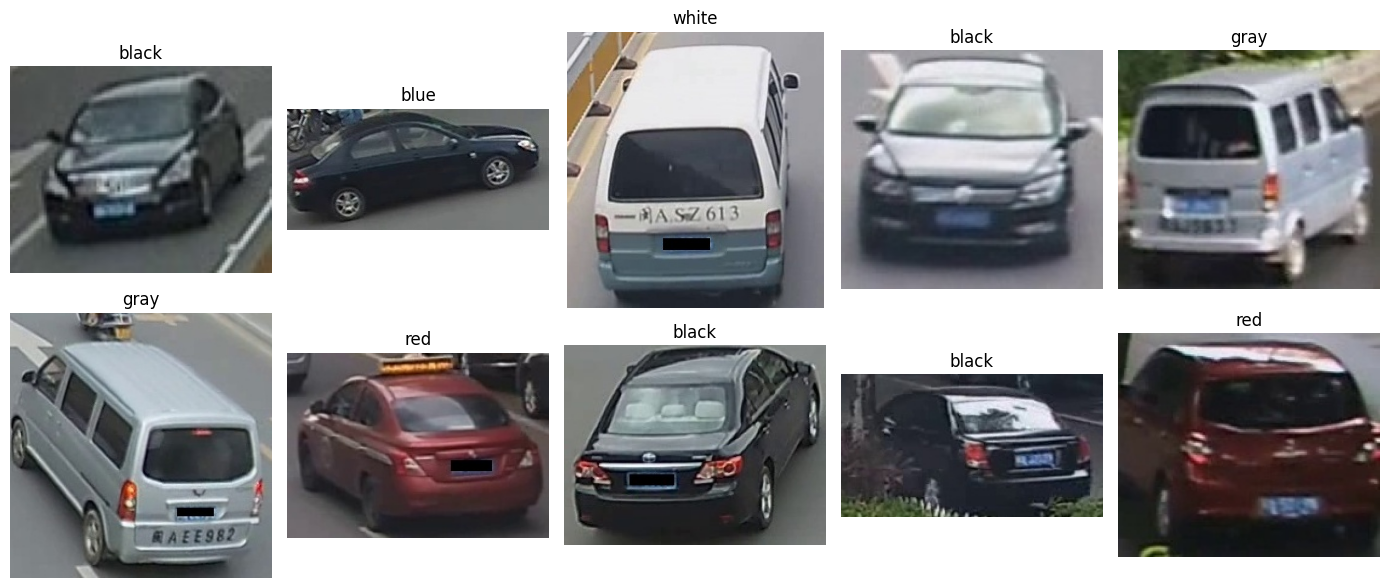

In [8]:
import os
import random
import matplotlib.pyplot as plt
import cv2
import xml.etree.ElementTree as ET

# المسارات
base_path = "/content/VeRi"
train_path = os.path.join(base_path, "image_train")

# --- ربط اسم الصورة باللون ---
img_to_color = {}

for item in root.iter():
    img_name = item.attrib.get("imageName")
    color_id = item.attrib.get("colorID")

    if img_name and color_id:
        img_to_color[img_name] = int(color_id)

# --- قراءة أسماء الألوان ---
color_names = {}
with open(os.path.join(base_path, "list_color.txt")) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            color_names[int(parts[0])] = parts[1]

# --- اختيار 10 صور ---
images = list(img_to_color.keys())
sample_images = random.sample(images, 10)

# --- عرض ---
plt.figure(figsize=(14, 6))

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(train_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    color_id = img_to_color.get(img_name, -1)
    color_label = color_names.get(color_id, f"Color {color_id}")

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(color_label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
import os
import xml.etree.ElementTree as ET
import pandas as pd

base_path = "/content/VeRi"
train_path = os.path.join(base_path, "image_train")

import xml.etree.ElementTree as ET

with open("/content/VeRi/train_label.xml", "rb") as f:
    data = f.read()

# تحويل إلى نص بدون أخطاء
data = data.decode("utf-8", errors="ignore")

# إعادة تحويل إلى XML
root = ET.fromstring(data)

# --- قراءة أسماء الألوان ---
color_names = {}
with open(os.path.join(base_path, "list_color.txt")) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            color_names[int(parts[0])] = parts[1]

# --- إنشاء البيانات ---
data = []

for item in root.iter():
    img_name = item.attrib.get("imageName")
    color_id = item.attrib.get("colorID")

    if img_name and color_id:
        img_path = os.path.join(train_path, img_name)

        # فقط الصور الموجودة
        if os.path.exists(img_path):
            color_id = int(color_id)
            color_name = color_names.get(color_id, "unknown")

            data.append([img_name, color_id, color_name])

# --- إنشاء DataFrame ---
df_train = pd.DataFrame(data, columns=["image_name", "color_id", "color_name"])

# --- حفظ CSV ---
csv_path = os.path.join(base_path, "train_colors.csv")
df_train.to_csv(csv_path, index=False)

print("✅ تم إنشاء الملف:", csv_path)
print("عدد الصفوف:", len(df_train))

✅ تم إنشاء الملف: /content/VeRi/train_colors.csv
عدد الصفوف: 37746


In [10]:
import os
import xml.etree.ElementTree as ET
import pandas as pd

base_path = "/content/VeRi"
train_path = os.path.join(base_path, "image_test")

import xml.etree.ElementTree as ET

with open("/content/VeRi/test_label.xml", "rb") as f:
    data = f.read()

# تحويل إلى نص بدون أخطاء
data = data.decode("utf-8", errors="ignore")

# إعادة تحويل إلى XML
root = ET.fromstring(data)

# --- قراءة أسماء الألوان ---
color_names = {}
with open(os.path.join(base_path, "list_color.txt")) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            color_names[int(parts[0])] = parts[1]

# --- إنشاء البيانات ---
data = []

for item in root.iter():
    img_name = item.attrib.get("imageName")
    color_id = item.attrib.get("colorID")

    if img_name and color_id:
        img_path = os.path.join(train_path, img_name)

        # فقط الصور الموجودة
        if os.path.exists(img_path):
            color_id = int(color_id)
            color_name = color_names.get(color_id, "unknown")

            data.append([img_name, color_id, color_name])

# --- إنشاء DataFrame ---
df_test = pd.DataFrame(data, columns=["image_name", "color_id", "color_name"])

# --- حفظ CSV ---
csv_path = os.path.join(base_path, "test_colors.csv")
df_test.to_csv(csv_path, index=False)

print("✅ تم إنشاء الملف:", csv_path)
print("عدد الصفوف:", len(df_test))

✅ تم إنشاء الملف: /content/VeRi/test_colors.csv
عدد الصفوف: 11579


In [11]:
cp -r "/content/VeRi/train_colors.csv"  "/content/drive/MyDrive/vcrh"

In [12]:
cp -r "/content/VeRi/test_colors.csv" "/content/drive/MyDrive/vcrh"

In [13]:
import pandas as pd
df_train=pd.read_csv("/content/VeRi/train_colors.csv")

In [14]:
df_train.head()

,image_name,color_id,color_name
0,0001_c001_00016450_0.jpg,1,yellow
1,0001_c001_00016460_0.jpg,1,yellow
2,0001_c001_00016470_0.jpg,1,yellow
3,0001_c001_00016480_0.jpg,1,yellow
4,0001_c001_00016490_0.jpg,1,yellow


In [15]:
# حول كل الألوان من 1-10 إلى 0-9
df_train['color_id'] = df_train['color_id'] - 1

In [16]:
color_counts = df_train["color_id"].value_counts().sort_index()

print(color_counts)

color_id
0    1311
1     160
2    1768
3    9088
4    4358
5    3243
6    6006
7    1723
8     882
9    9207
Name: count, dtype: int64


In [17]:
import pandas as pd

#df_train = pd.read_csv("/content/VeRi/train_colors.csv")

# تجميع حسب اللون
counts = df_train.groupby(["color_id", "color_name"]).size().reset_index(name="count")

# ترتيب تنازلي
counts = counts.sort_values(by="count", ascending=False)

print(counts)

   color_id color_name  count
9         9      black   9207
3         3       gray   9088
6         6      white   6006
4         4        red   4358
5         5       blue   3243
2         2      green   1768
7         7     golden   1723
0         0     yellow   1311
8         8      brown    882
1         1     orange    160


/tmp/ipykernel_1722/2579235348.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=color_counts.index, y=color_counts.values, palette="viridis")


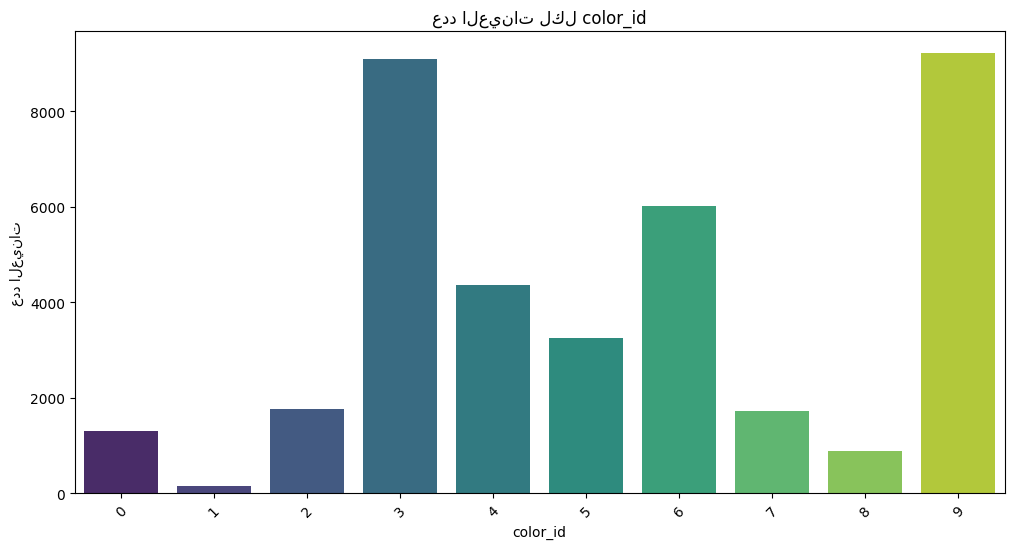

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
color_counts = df_train["color_id"].value_counts().sort_index()

# إعداد الرسم
plt.figure(figsize=(12,6))
sns.barplot(x=color_counts.index, y=color_counts.values, palette="viridis")

plt.title("عدد العينات لكل color_id")
plt.xlabel("color_id")
plt.ylabel("عدد العينات")
plt.xticks(rotation=45)  # إذا كان هناك أرقام كبيرة لتدوير التسميات
plt.show()

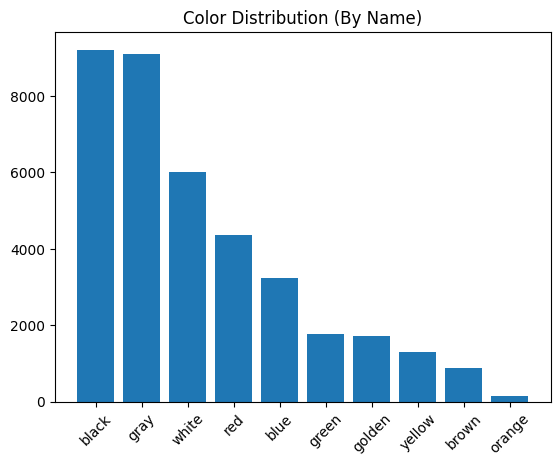

In [20]:
color_counts_named = df_train["color_name"].value_counts()

plt.figure()
plt.bar(color_counts_named.index, color_counts_named.values)
plt.xticks(rotation=45)
plt.title("Color Distribution (By Name)")
plt.show()

In [26]:
df_train = df_train.groupby("color_id").head(5000)

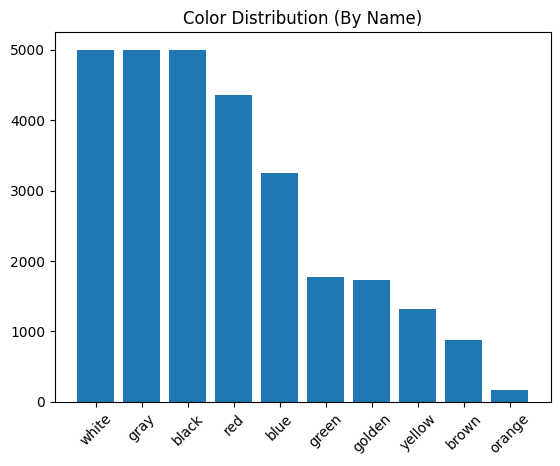

In [27]:
color_counts_named = df_train["color_name"].value_counts()

plt.figure()
plt.bar(color_counts_named.index, color_counts_named.values)
plt.xticks(rotation=45)
plt.title("Color Distribution (By Name)")
plt.show()

In [28]:
df_train["label"]= df_train["color_id"]

In [29]:
df_train.head()

,image_name,color_id,color_name,label
0,0001_c001_00016450_0.jpg,0,yellow,0
1,0001_c001_00016460_0.jpg,0,yellow,0
2,0001_c001_00016470_0.jpg,0,yellow,0
3,0001_c001_00016480_0.jpg,0,yellow,0
4,0001_c001_00016490_0.jpg,0,yellow,0


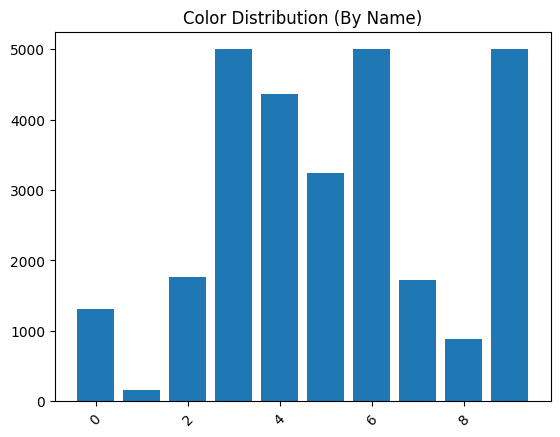

In [30]:
color_counts_named = df_train["label"].value_counts()

plt.figure()
plt.bar(color_counts_named.index, color_counts_named.values)
plt.xticks(rotation=45)
plt.title("Color Distribution (By Name)")
plt.show()

In [31]:
# ================== 1) تثبيت ==================
#!pip install timm

# ================== 2) استيراد ==================
import os
import cv2
import torch
import timm
import pandas as pd
import numpy as np
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


In [32]:
print(type(df_train))
print(len(df_train))
print("df_train:", len(df_train))
# إذا عندك y
print("y:", len(df_train["color_id"]))

<class 'pandas.core.frame.DataFrame'>
28445
df_train: 28445
y: 28445


In [33]:

# ================== 3) إعداد الجهاز ==================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================== 4) قراءة CSV وتقسيم ==================
#df = pd.read_csv("/content/VeRi/train_colors.csv")
#df=df_balanced
train_df, val_df = train_test_split(
    df_train,
    test_size=0.3,
    stratify=df_train["color_id"],
    random_state=42
)

train_df.to_csv("/content/VeRi/train_split.csv", index=False)
val_df.to_csv("/content/VeRi/val_split.csv", index=False)


In [34]:
cp -r /content/VeRi/train_split.csv "/content/drive/MyDrive/vcrh"

In [35]:
cp -r /content/VeRi/val_split.csv "/content/drive/MyDrive/vcrh"

In [36]:
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    #transforms.RandomHorizontalFlip(),
    #transforms.RandomRotation(10),
    #transforms.ColorJitter(brightness=0.3, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class CarDataset(Dataset):

    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.targets = self.df["label"].values
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_path =os.path.join('/content/VeRi/image_train', self.df.loc[idx,"image_name"])
        label = self.df.loc[idx,"label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [37]:
from torch.utils.data import DataLoader

train_dataset = CarDataset(train_df, transform)
val_dataset = CarDataset(val_df, transform)
#test_dataset = CarDataset(test_df, transform)

train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=64)
#test_loader = DataLoader(test_dataset,batch_size=64)

In [38]:
y_train = train_loader.dataset.targets

In [40]:
import torch.nn as nn
import torchvision.models as models

#num_classes = len(le.classes_)
num_classes = 10

model = models.resnet50(pretrained=True)

model.fc = nn.Sequential(
    #nn.Dropout(0.6),
    nn.Linear(model.fc.in_features, num_classes)
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 118MB/s]


In [41]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.000001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=1
)

In [42]:
import torch
import json

class EarlyStopping:
    def __init__(self, patience=2, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return False

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            return True

        return False


early_stopping = EarlyStopping(patience=5)
best_loss = float("inf")
num_epochs = 4

train_losses = []
val_losses = []

for epoch in range(num_epochs):


    model.train()
    train_loss = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | Batch [{batch_idx+1}/{len(train_loader)}] | Loss: {loss.item():.4f}")


    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()


    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    print(f"\nEpoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")


    train_losses.append(train_loss)
    val_losses.append(val_loss)


    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ تم حفظ أفضل موديل")


    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': val_loss,
    }, "checkpoint.pth")


    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr != old_lr:
        print(f"🔻 LR changed from {old_lr} to {new_lr}")



    if early_stopping.step(val_loss):
        print("⛔ تم إيقاف التدريب (Early Stopping)")
        break

    print("Current LR:", optimizer.param_groups[0]['lr'])


with open("losses.json", "w") as f:
    json.dump({
        "train_losses": train_losses,
        "val_losses": val_losses
    }, f)

print("💾 تم حفظ loss في losses.json")

Epoch [1/4] | Batch [50/312] | Loss: 2.2118
Epoch [1/4] | Batch [100/312] | Loss: 2.1171
Epoch [1/4] | Batch [150/312] | Loss: 2.2014
Epoch [1/4] | Batch [200/312] | Loss: 2.1112
Epoch [1/4] | Batch [250/312] | Loss: 2.0702
Epoch [1/4] | Batch [300/312] | Loss: 1.8992

Epoch 0: Train Loss=2.1502, Val Loss=1.9733
✅ تم حفظ أفضل موديل
Current LR: 1e-06
Epoch [2/4] | Batch [50/312] | Loss: 1.8340
Epoch [2/4] | Batch [100/312] | Loss: 1.9272
Epoch [2/4] | Batch [150/312] | Loss: 1.8005
Epoch [2/4] | Batch [200/312] | Loss: 1.6982
Epoch [2/4] | Batch [250/312] | Loss: 1.4581
Epoch [2/4] | Batch [300/312] | Loss: 1.7529

Epoch 1: Train Loss=1.7759, Val Loss=1.5776
✅ تم حفظ أفضل موديل
Current LR: 1e-06
Epoch [3/4] | Batch [50/312] | Loss: 1.4120
Epoch [3/4] | Batch [100/312] | Loss: 1.5114
Epoch [3/4] | Batch [150/312] | Loss: 1.5224
Epoch [3/4] | Batch [200/312] | Loss: 1.3602
Epoch [3/4] | Batch [250/312] | Loss: 1.3609
Epoch [3/4] | Batch [300/312] | Loss: 1.2499

Epoch 2: Train Loss=1.4063

In [45]:
!cp -r /content/best_model.pth /content/drive/MyDrive/vcrh
!cp -r /content/checkpoint.pth /content/drive/MyDrive/vcrh
!cp -r /content/losses.json /content/drive/MyDrive/vcrh

In [47]:
import torch
import json


checkpoint = torch.load("/content/checkpoint.pth")

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

start_epoch = checkpoint['epoch'] + 1
best_loss = checkpoint['loss']

print("🔁 استكمال التدريب من epoch:", start_epoch)



class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return False

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1

        return self.counter >= self.patience


early_stopping = EarlyStopping(patience=5)

num_epochs = 4

train_losses = []
val_losses = []

for epoch in range(start_epoch, start_epoch + num_epochs):

    model.train()
    train_loss = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            print(f"Epoch [{epoch}] | Batch [{batch_idx+1}/{len(train_loader)}] | Loss: {loss.item():.4f}")

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    print(f"\nEpoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    train_losses.append(train_loss)
    val_losses.append(val_loss)


    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ تم حفظ أفضل موديل")


    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': val_loss,
    }, "checkpoint.pth")


    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr != old_lr:
        print(f"🔻 LR changed from {old_lr} to {new_lr}")


    if early_stopping.step(val_loss):
        print("⛔ تم إيقاف التدريب")
        break

    print("Current LR:", optimizer.param_groups[0]['lr'])



with open("losses_resume.json", "w") as f:
    json.dump({
        "train_losses": train_losses,
        "val_losses": val_losses
    }, f)

print("💾 تم حفظ loss")

🔁 استكمال التدريب من epoch: 4
Epoch [4] | Batch [50/312] | Loss: 1.0417
Epoch [4] | Batch [100/312] | Loss: 0.6474
Epoch [4] | Batch [150/312] | Loss: 0.6524
Epoch [4] | Batch [200/312] | Loss: 0.6760
Epoch [4] | Batch [250/312] | Loss: 0.6090
Epoch [4] | Batch [300/312] | Loss: 0.8966

Epoch 4: Train Loss=0.8717, Val Loss=0.7644
✅ تم حفظ أفضل موديل
Current LR: 1e-06
Epoch [5] | Batch [50/312] | Loss: 0.8755
Epoch [5] | Batch [100/312] | Loss: 0.6994
Epoch [5] | Batch [150/312] | Loss: 0.5382
Epoch [5] | Batch [200/312] | Loss: 0.4741
Epoch [5] | Batch [250/312] | Loss: 0.6437
Epoch [5] | Batch [300/312] | Loss: 0.8327

Epoch 5: Train Loss=0.6890, Val Loss=0.6287
✅ تم حفظ أفضل موديل
Current LR: 1e-06
Epoch [6] | Batch [50/312] | Loss: 0.5931
Epoch [6] | Batch [100/312] | Loss: 0.4621
Epoch [6] | Batch [150/312] | Loss: 0.5794
Epoch [6] | Batch [200/312] | Loss: 0.7244
Epoch [6] | Batch [250/312] | Loss: 0.4955
Epoch [6] | Batch [300/312] | Loss: 0.4724

Epoch 6: Train Loss=0.5579, Val 

In [50]:
import torch
import json


checkpoint = torch.load("/content/checkpoint.pth")

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

start_epoch = checkpoint['epoch'] + 1
best_loss = checkpoint['loss']

print("🔁 استكمال التدريب من epoch:", start_epoch)



class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return False

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1

        return self.counter >= self.patience


early_stopping = EarlyStopping(patience=5)

num_epochs = 3

train_losses = []
val_losses = []

for epoch in range(start_epoch, start_epoch + num_epochs):

    model.train()
    train_loss = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            print(f"Epoch [{epoch}] | Batch [{batch_idx+1}/{len(train_loader)}] | Loss: {loss.item():.4f}")

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    print(f"\nEpoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    train_losses.append(train_loss)
    val_losses.append(val_loss)


    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ تم حفظ أفضل موديل")


    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': val_loss,
    }, "checkpoint.pth")


    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr != old_lr:
        print(f"🔻 LR changed from {old_lr} to {new_lr}")


    if early_stopping.step(val_loss):
        print("⛔ تم إيقاف التدريب")
        break

    print("Current LR:", optimizer.param_groups[0]['lr'])



with open("losses_resume.json", "w") as f:
    json.dump({
        "train_losses": train_losses,
        "val_losses": val_losses
    }, f)

print("💾 تم حفظ loss")

🔁 استكمال التدريب من epoch: 8
Epoch [8] | Batch [50/312] | Loss: 0.5205
Epoch [8] | Batch [100/312] | Loss: 0.3661
Epoch [8] | Batch [150/312] | Loss: 0.3021
Epoch [8] | Batch [200/312] | Loss: 0.6065
Epoch [8] | Batch [250/312] | Loss: 0.3658
Epoch [8] | Batch [300/312] | Loss: 0.3811

Epoch 8: Train Loss=0.3758, Val Loss=0.3421
✅ تم حفظ أفضل موديل
Current LR: 1e-06
Epoch [9] | Batch [50/312] | Loss: 0.4672
Epoch [9] | Batch [100/312] | Loss: 0.3773
Epoch [9] | Batch [150/312] | Loss: 0.3216
Epoch [9] | Batch [200/312] | Loss: 0.2912
Epoch [9] | Batch [250/312] | Loss: 0.2209
Epoch [9] | Batch [300/312] | Loss: 0.3733

Epoch 9: Train Loss=0.3088, Val Loss=0.2971
✅ تم حفظ أفضل موديل
Current LR: 1e-06
Epoch [10] | Batch [50/312] | Loss: 0.3208
Epoch [10] | Batch [100/312] | Loss: 0.3388
Epoch [10] | Batch [150/312] | Loss: 0.1528
Epoch [10] | Batch [200/312] | Loss: 0.2011
Epoch [10] | Batch [250/312] | Loss: 0.2773
Epoch [10] | Batch [300/312] | Loss: 0.2356

Epoch 10: Train Loss=0.254

In [55]:
import torch
import json


checkpoint = torch.load("/content/checkpoint.pth")

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

start_epoch = checkpoint['epoch'] + 1
best_loss = checkpoint['loss']

print("🔁 استكمال التدريب من epoch:", start_epoch)



class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return False

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1

        return self.counter >= self.patience


early_stopping = EarlyStopping(patience=5)

num_epochs = 2

train_losses = []
val_losses = []

for epoch in range(start_epoch, start_epoch + num_epochs):

    model.train()
    train_loss = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            print(f"Epoch [{epoch}] | Batch [{batch_idx+1}/{len(train_loader)}] | Loss: {loss.item():.4f}")

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    print(f"\nEpoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    train_losses.append(train_loss)
    val_losses.append(val_loss)


    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ تم حفظ أفضل موديل")


    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': val_loss,
    }, "checkpoint.pth")


    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr != old_lr:
        print(f"🔻 LR changed from {old_lr} to {new_lr}")


    if early_stopping.step(val_loss):
        print("⛔ تم إيقاف التدريب")
        break

    print("Current LR:", optimizer.param_groups[0]['lr'])



with open("losses_resume.json", "w") as f:
    json.dump({
        "train_losses": train_losses,
        "val_losses": val_losses
    }, f)

print("💾 تم حفظ loss")

🔁 استكمال التدريب من epoch: 11
Epoch [11] | Batch [50/312] | Loss: 0.1830
Epoch [11] | Batch [100/312] | Loss: 0.2365
Epoch [11] | Batch [150/312] | Loss: 0.1169
Epoch [11] | Batch [200/312] | Loss: 0.1300
Epoch [11] | Batch [250/312] | Loss: 0.1763
Epoch [11] | Batch [300/312] | Loss: 0.2581

Epoch 11: Train Loss=0.2148, Val Loss=0.2115
✅ تم حفظ أفضل موديل
Current LR: 1e-06
Epoch [12] | Batch [50/312] | Loss: 0.2471
Epoch [12] | Batch [100/312] | Loss: 0.1211
Epoch [12] | Batch [150/312] | Loss: 0.2222
Epoch [12] | Batch [200/312] | Loss: 0.1516
Epoch [12] | Batch [250/312] | Loss: 0.2107
Epoch [12] | Batch [300/312] | Loss: 0.1990

Epoch 12: Train Loss=0.1814, Val Loss=0.1899
✅ تم حفظ أفضل موديل
Current LR: 1e-06
💾 تم حفظ loss


In [60]:
import torch
import json


checkpoint = torch.load("/content/checkpoint.pth")

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

start_epoch = checkpoint['epoch'] + 1
best_loss = checkpoint['loss']

print("🔁 استكمال التدريب من epoch:", start_epoch)



class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return False

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1

        return self.counter >= self.patience


early_stopping = EarlyStopping(patience=5)

num_epochs = 2

train_losses = []
val_losses = []

for epoch in range(start_epoch, start_epoch + num_epochs):

    model.train()
    train_loss = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            print(f"Epoch [{epoch}] | Batch [{batch_idx+1}/{len(train_loader)}] | Loss: {loss.item():.4f}")

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    print(f"\nEpoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    train_losses.append(train_loss)
    val_losses.append(val_loss)


    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ تم حفظ أفضل موديل")


    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': val_loss,
    }, "checkpoint.pth")


    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr != old_lr:
        print(f"🔻 LR changed from {old_lr} to {new_lr}")


    if early_stopping.step(val_loss):
        print("⛔ تم إيقاف التدريب")
        break

    print("Current LR:", optimizer.param_groups[0]['lr'])



with open("losses_resume.json", "w") as f:
    json.dump({
        "train_losses": train_losses,
        "val_losses": val_losses
    }, f)

print("💾 تم حفظ loss")

🔁 استكمال التدريب من epoch: 13
Epoch [13] | Batch [50/312] | Loss: 0.1659
Epoch [13] | Batch [100/312] | Loss: 0.1587
Epoch [13] | Batch [150/312] | Loss: 0.1997
Epoch [13] | Batch [200/312] | Loss: 0.1405
Epoch [13] | Batch [250/312] | Loss: 0.1746
Epoch [13] | Batch [300/312] | Loss: 0.1250

Epoch 13: Train Loss=0.1545, Val Loss=0.1689
✅ تم حفظ أفضل موديل
Current LR: 1e-06
Epoch [14] | Batch [50/312] | Loss: 0.1564
Epoch [14] | Batch [100/312] | Loss: 0.1527
Epoch [14] | Batch [150/312] | Loss: 0.0960
Epoch [14] | Batch [200/312] | Loss: 0.1562
Epoch [14] | Batch [250/312] | Loss: 0.1124
Epoch [14] | Batch [300/312] | Loss: 0.1764

Epoch 14: Train Loss=0.1327, Val Loss=0.1501
✅ تم حفظ أفضل موديل
Current LR: 1e-06
💾 تم حفظ loss


In [72]:
import torch
import json


checkpoint = torch.load("/content/checkpoint.pth")

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

start_epoch = checkpoint['epoch'] + 1
best_loss = checkpoint['loss']

print("🔁 استكمال التدريب من epoch:", start_epoch)



class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return False

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1

        return self.counter >= self.patience


early_stopping = EarlyStopping(patience=5)

num_epochs = 2

train_losses = []
val_losses = []

for epoch in range(start_epoch, start_epoch + num_epochs):

    model.train()
    train_loss = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            print(f"Epoch [{epoch}] | Batch [{batch_idx+1}/{len(train_loader)}] | Loss: {loss.item():.4f}")

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    print(f"\nEpoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    train_losses.append(train_loss)
    val_losses.append(val_loss)


    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ تم حفظ أفضل موديل")


    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': val_loss,
    }, "checkpoint.pth")


    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr != old_lr:
        print(f"🔻 LR changed from {old_lr} to {new_lr}")


    if early_stopping.step(val_loss):
        print("⛔ تم إيقاف التدريب")
        break

    print("Current LR:", optimizer.param_groups[0]['lr'])



with open("losses_resume.json", "w") as f:
    json.dump({
        "train_losses": train_losses,
        "val_losses": val_losses
    }, f)

print("💾 تم حفظ loss")

🔁 استكمال التدريب من epoch: 15
Epoch [15] | Batch [50/312] | Loss: 0.1177
Epoch [15] | Batch [100/312] | Loss: 0.1486
Epoch [15] | Batch [150/312] | Loss: 0.1146
Epoch [15] | Batch [200/312] | Loss: 0.0474
Epoch [15] | Batch [250/312] | Loss: 0.1839
Epoch [15] | Batch [300/312] | Loss: 0.1243

Epoch 15: Train Loss=0.1213, Val Loss=0.1359
✅ تم حفظ أفضل موديل
Current LR: 1e-06
Epoch [16] | Batch [50/312] | Loss: 0.1068
Epoch [16] | Batch [100/312] | Loss: 0.1151
Epoch [16] | Batch [150/312] | Loss: 0.0864
Epoch [16] | Batch [200/312] | Loss: 0.0492
Epoch [16] | Batch [250/312] | Loss: 0.1307
Epoch [16] | Batch [300/312] | Loss: 0.0654

Epoch 16: Train Loss=0.1015, Val Loss=0.1228
✅ تم حفظ أفضل موديل
Current LR: 1e-06
💾 تم حفظ loss


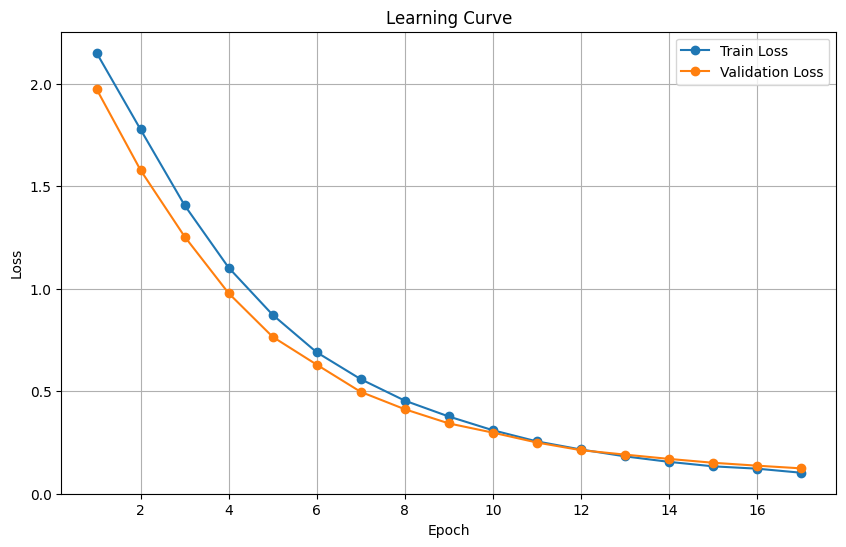

In [80]:
import matplotlib.pyplot as plt

# ضع القيم التي ظهرت عندك في التدريب
train_losses = [
    2.1502, 1.7759, 1.4063, 1.1019,
    0.8717, 0.6890, 0.5579, 0.4532,
    0.3758, 0.3088, 0.2543, 0.2148 ,0.1814 ,0.1545 ,0.1327 ,0.1213,0.1015
]

val_losses = [
    1.9733, 1.5776, 1.2536, 0.9771,
    0.7644, 0.6287, 0.4959, 0.4113,
    0.3421, 0.2971, 0.2489, 0.2115 ,0.1899 , 0.1689 ,0.1501 ,0.1359,0.1228
]

epochs = list(range(1, len(train_losses) + 1))

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_losses, label="Train Loss", marker='o')
plt.plot(epochs, val_losses, label="Validation Loss", marker='o')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)

plt.show()

In [73]:
!cp -r /content/best_model.pth /content/drive/MyDrive/vcrh
!cp -r /content/checkpoint.pth /content/drive/MyDrive/vcrh
!cp -r /content/losses.json /content/drive/MyDrive/vcrh
!cp -r /content/losses_resume.json /content/drive/MyDrive/vcrh

In [75]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()  # مهم جدًا للتقييم
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import os

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class TestDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join('/content/VeRi/image_test', self.df.loc[idx, "image_name"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image


test_df=pd.read_csv("/content/VeRi/test_colors.csv")
test_loader = DataLoader(
    TestDataset(test_df, transform=test_transform),
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [76]:
all_preds = []

with torch.no_grad():
    for images in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())


test_df['color_id'] = test_df['color_id'] - 1
test_df["label"]= test_df["color_id"]

test_dataset = CarDataset(test_df, transform)
test_loader = DataLoader(test_dataset,batch_size=64)

In [77]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import os
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# --- إعداد التحويلات ---
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Dataset للاختبار مع تجاهل الصور المفقودة ---
class TestDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.image_dir = image_dir
        # فلترة الصور الموجودة فقط
        self.df = self.df[self.df["image_name"].apply(
            lambda x: os.path.exists(os.path.join(self.image_dir, x))
        )].reset_index(drop=True)
        print(f"عدد الصور المتاحة للاختبار: {len(self.df)}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.df.loc[idx, "image_name"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = self.df.loc[idx, "label"]  # تأكد أن لديك الليبل في CSV
        return image, label

# --- إعداد DataLoader ---
test_dataset = TestDataset(test_df, '/content/VeRi/image_test', transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# --- وضع الموديل في وضع التقييم ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# --- التنبؤات ---
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# --- الطباعة والتقارير ---
print("\n========== Classification Report ==========")
print(classification_report(all_labels, all_preds, digits=4))

print("\n========== Confusion Matrix ==========")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

عدد الصور المتاحة للاختبار: 11579

========== Classification Report ==========
              precision    recall  f1-score   support

           0     0.9854    0.8855    0.9328       760
           1     0.9271    0.7542    0.8318       118
           2     0.8765    0.9413    0.9077       716
           3     0.9358    0.8315    0.8806      1822
           4     0.9397    0.9791    0.9590      1099
           5     0.7203    0.9732    0.8279       299
           6     0.9397    0.9579    0.9487      2520
           7     0.4970    0.9709    0.6575       172
           8     0.4539    0.3386    0.3879       189
           9     0.9801    0.9632    0.9716      3884

    accuracy                         0.9244     11579
   macro avg     0.8255    0.8596    0.8305     11579
weighted avg     0.9314    0.9244    0.9253     11579


========== Confusion Matrix ==========
[[ 673    7    0    0    0   52   18   10    0    0]
 [   0   89    0    0   26    0    0    1    2    0]
 [   0    0  674

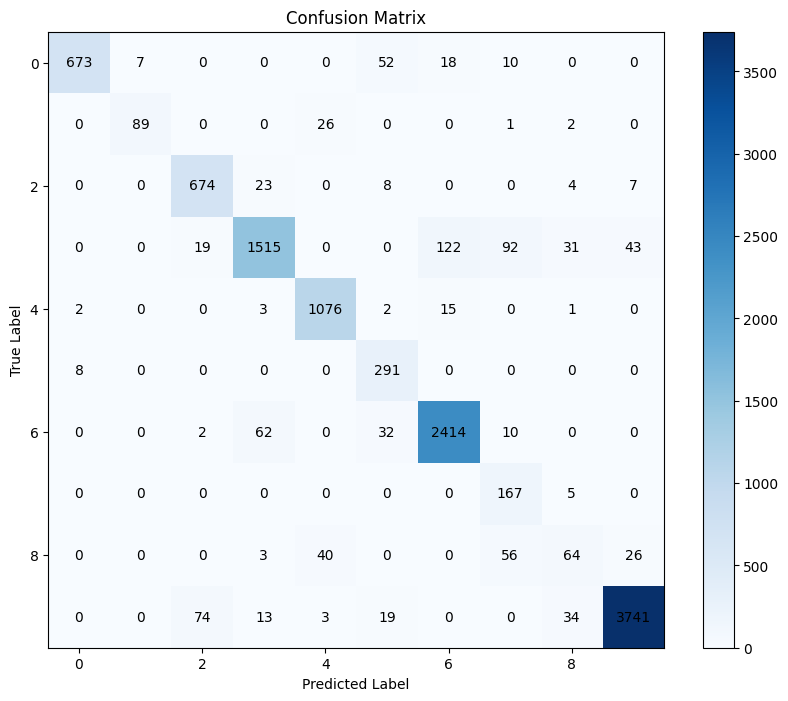

In [79]:
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([
    [673, 7, 0, 0, 0, 52, 18, 10, 0, 0],
    [0, 89, 0, 0, 26, 0, 0, 1, 2, 0],
    [0, 0, 674, 23, 0, 8, 0, 0, 4, 7],
    [0, 0, 19, 1515, 0, 0, 122, 92, 31, 43],
    [2, 0, 0, 3, 1076, 2, 15, 0, 1, 0],
    [8, 0, 0, 0, 0, 291, 0, 0, 0, 0],
    [0, 0, 2, 62, 0, 32, 2414, 10, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 167, 5, 0],
    [0, 0, 0, 3, 40, 0, 0, 56, 64, 26],
    [0, 0, 74, 13, 3, 19, 0, 0, 34, 3741]
])

plt.figure(figsize=(10, 8))

plt.imshow(cm, cmap='Blues')
plt.colorbar()

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# إضافة القيم داخل المربعات
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="black")

plt.show()

In [78]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- حساب المقاييس ---
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

# --- عرض النتائج ---
print("\n========== Results ==========")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


========== Results ==========
Accuracy : 0.9244
Precision: 0.9314
Recall   : 0.9244
F1-score : 0.9253
